In [5]:
from langgraph.graph import StateGraph,START,MessagesState,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv


In [9]:
model=chat = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

In [10]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [11]:
builder=StateGraph(MessagesState)
builder.add_node(call_model,"call_model")
builder.add_edge(START,"call_model")
builder.add_edge("call_model",END)
graph=builder.compile()

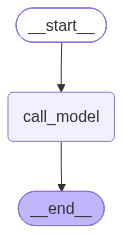

In [12]:
graph

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='7cc156d1-3118-4ad1-ac5a-5f94cbf2e5db'),
  AIMessage(content='Hi Nitish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8864-1b04-7cb3-9050-4b08c21dc105-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 49, 'total_tokens': 58, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 33}})]}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='0307ceb4-0108-43d5-920e-318cd4f6e4a2'),
  AIMessage(content="As an AI, I don't have access to personal information about you, including your name. I don't retain memory of who you are from one interaction to the next.\n\nYou'll have to tell me your name if you'd like me to know it!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8864-f891-7351-b09b-c15bf0ed428c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 555, 'total_tokens': 561, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 498}})]}

In [15]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [16]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [17]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [18]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [19]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='cd5d5146-c23a-45d3-8ac5-e3b67ccd785a'),
  AIMessage(content='Hi Nitish! Nice to meet you.\n\nHow can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8866-a7bc-73b0-9413-80eb68774bfa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 456, 'total_tokens': 465, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 439}})]}

In [21]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='cd5d5146-c23a-45d3-8ac5-e3b67ccd785a'),
  AIMessage(content='Hi Nitish! Nice to meet you.\n\nHow can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8866-a7bc-73b0-9413-80eb68774bfa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 456, 'total_tokens': 465, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 439}}),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='e9a9f391-c579-4184-aa74-e53c88cc000c'),
  AIMessage(content='Your name is Nitish.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8867-461

In [22]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='d1779e1a-f1a8-4372-899a-b803532c0028'),
  AIMessage(content="As an AI, I don't have access to personal information about you, including your name. I don't know who you are.\n\nIf you'd like to tell me, I'm happy to know it for our conversation!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8867-7ab2-7df0-a07f-b276ff09e924-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 337, 'total_tokens': 343, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 287}})]}

In [23]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish.
- AIMessage : Hi Nitish! Nice to meet you.

How can I help you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Nitish.
